#📌 Extracción

Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

In [38]:
#librerias
import requests
import base64
import json
import pandas as pd
import numpy as np

In [39]:
# Obtener info del archivo
contents_url = "https://api.github.com/repos/ingridcristh/challenge2-data-science-LATAM/contents/TelecomX_Data.json"

response = requests.get(contents_url)
file_info = response.json()

# Obtener SHA automáticamente
sha = file_info["sha"]

# Construir URL del blob
blob_url = f"https://api.github.com/repos/ingridcristh/challenge2-data-science-LATAM/git/blobs/{sha}"

blob_response = requests.get(blob_url)
blob_data = blob_response.json()

# Decodificar
content = base64.b64decode(blob_data["content"]).decode("utf-8")

data = json.loads(content)

df = pd.DataFrame(data)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [40]:
#Explorar las columnas del dataset y verificar sus tipos de datos.
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [41]:
# Empezamos con las columnas que ya están 'planas': customerID y Churn
df_final = df[['customerID', 'Churn']].copy()

# Normalizamos la columna 'customer'
customer_cols = pd.json_normalize(df['customer'])
# Le añadimos un prefijo para evitar colisiones de nombres con otras columnas si hubiera
df_final = pd.concat([df_final, customer_cols.add_prefix('customer_')], axis=1)

# Normalizamos la columna 'phone'
phone_cols = pd.json_normalize(df['phone'])
df_final = pd.concat([df_final, phone_cols.add_prefix('phone_')], axis=1)

# Normalizamos la columna 'internet'
internet_cols = pd.json_normalize(df['internet'])
df_final = pd.concat([df_final, internet_cols.add_prefix('internet_')], axis=1)

# Normalizamos la columna 'account'.
# json_normalize ya expandirá 'Charges.Monthly' y 'Charges.Total' directamente.
account_cols = pd.json_normalize(df['account'])

# Añadimos un prefijo a las columnas de 'account' para evitar colisiones
account_cols = account_cols.add_prefix('account_')

# Concatenamos las columnas a df_final
df_final = pd.concat([df_final, account_cols], axis=1)

# Asignamos el DataFrame final a la variable 'datos'
datos = df_final

# Mostramos las primeras filas del nuevo DataFrame aplanado
datos.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [42]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

✅ Consultar el diccionario para comprender mejor el significado de las variables.



```
#
customerID: número de identificación único de cada cliente
Churn: si el cliente dejó o no la empresa
gender: género (masculino y femenino)
SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
Partner: si el cliente tiene o no una pareja
Dependents: si el cliente tiene o no dependientes
tenure: meses de contrato del cliente
PhoneService: suscripción al servicio telefónico
MultipleLines: suscripción a más de una línea telefónica
InternetService: suscripción a un proveedor de internet
OnlineSecurity: suscripción adicional de seguridad en línea
OnlineBackup: suscripción adicional de respaldo en línea
DeviceProtection: suscripción adicional de protección del dispositivo
TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
StreamingTV: suscripción de televisión por cable
StreamingMovies: suscripción de streaming de películas
Contract: tipo de contrato
PaperlessBilling: si el cliente prefiere recibir la factura en línea
PaymentMethod: forma de pago
Charges.Monthly: total de todos los servicios del cliente por mes
Charges.Total: total gastado por el cliente
```



✅ Identificar las columnas más relevantes para el análisis de evasión.

* 1️⃣ tenure (meses con la empresa)

  Clientes nuevos cancelan más.

  Clientes con más tiempo suelen quedarse.

  Altamente predictiva.

* 2️⃣ Contract (tipo de contrato)

  Mes a mes → mayor churn

  1 año / 2 años → menor churn

  Esta variable normalmente explica muchísimo.

3️⃣ Charges.Monthly

  Si el costo mensual es alto:

  Puede aumentar probabilidad de cancelación.

  Pero depende del valor percibido.

4️⃣ Charges.Total

Está relacionada con tenure, pero ayuda a entender:

Cuánto ha invertido el cliente en la empresa.


5️⃣ InternetService

Muchos churn ocurren en clientes con fibra óptica (en datasets típicos tipo telecom).


6️⃣ Servicios adicionales

Variables como:

OnlineSecurity

TechSupport

DeviceProtection

Suelen ser importantes porque:clientes con más servicio tienden a cancelar más.

In [43]:
selected_columns = [
    'customerID',
    'Churn',
    'customer_tenure',
    'account_Contract',
    'account_Charges.Monthly',
    'account_Charges.Total',
    'internet_InternetService',
    'internet_OnlineSecurity',
    'internet_TechSupport',
    'internet_DeviceProtection'
]

# Filtrar el DataFrame para mantener solo las columnas seleccionadas y crear una copia explícita
datos = datos[selected_columns].copy()

# Mostrar las primeras filas del DataFrame con las columnas seleccionadas
datos.head()

,customerID,Churn,customer_tenure,account_Contract,account_Charges.Monthly,account_Charges.Total,internet_InternetService,internet_OnlineSecurity,internet_TechSupport,internet_DeviceProtection
0,0002-ORFBO,No,9,One year,65.6,593.3,DSL,No,Yes,No
1,0003-MKNFE,No,9,Month-to-month,59.9,542.4,DSL,No,No,No
2,0004-TLHLJ,Yes,4,Month-to-month,73.9,280.85,Fiber optic,No,No,Yes
3,0011-IGKFF,Yes,13,Month-to-month,98.0,1237.85,Fiber optic,No,No,Yes
4,0013-EXCHZ,Yes,3,Month-to-month,83.9,267.4,Fiber optic,No,Yes,No


In [44]:
columns_to_convert = [
    'customerID',
    'Churn',
    'internet_InternetService',
    'internet_OnlineSecurity',
    'internet_TechSupport',
    'internet_DeviceProtection',
    'account_Contract'
]

for col in columns_to_convert:
    if col in datos.columns:
        datos[col] = datos[col].astype('string')
    else:
        print(f"Advertencia: La columna '{col}' no se encontró en el DataFrame y no fue convertida.")

# Convertir 'account_Charges.Total' a tipo numérico, manejando errores
if 'account_Charges.Total' in datos.columns:
    datos['account_Charges.Total'] = pd.to_numeric(datos['account_Charges.Total'], errors='coerce')

In [45]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   string 
 1   Churn                      7267 non-null   string 
 2   customer_tenure            7267 non-null   int64  
 3   account_Contract           7267 non-null   string 
 4   account_Charges.Monthly    7267 non-null   float64
 5   account_Charges.Total      7256 non-null   float64
 6   internet_InternetService   7267 non-null   string 
 7   internet_OnlineSecurity    7267 non-null   string 
 8   internet_TechSupport       7267 non-null   string 
 9   internet_DeviceProtection  7267 non-null   string 
dtypes: float64(2), int64(1), string(7)
memory usage: 567.9 KB


In [46]:
print("Valores únicos por columna en el DataFrame 'datos':\n")

for col in datos.columns:
    print(f"Columna '{col}': {datos[col].unique()}")
    print("\n")

Valores únicos por columna en el DataFrame 'datos':

Columna 'customerID': <StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: string


Columna 'Churn': <StringArray>
['No', 'Yes', '']
Length: 3, dtype: string


Columna 'customer_tenure': [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


Columna 'account_Contract': <StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: string


Columna 'account_Charges.Monthly': [65.6  59.9  73.9  ... 91.75 68.8  67.85]


Columna 'account_Charges.Total': [ 593.3   542.4   280.85 ...  742.9  46

In [47]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   string 
 1   Churn                      7267 non-null   string 
 2   customer_tenure            7267 non-null   int64  
 3   account_Contract           7267 non-null   string 
 4   account_Charges.Monthly    7267 non-null   float64
 5   account_Charges.Total      7256 non-null   float64
 6   internet_InternetService   7267 non-null   string 
 7   internet_OnlineSecurity    7267 non-null   string 
 8   internet_TechSupport       7267 non-null   string 
 9   internet_DeviceProtection  7267 non-null   string 
dtypes: float64(2), int64(1), string(7)
memory usage: 567.9 KB


### Usando `pandas.unique()` para verificar duplicados en una columna

Con `pandas.unique()`, puedes verificar si una columna tiene valores duplicados comparando el número de valores únicos con el número total de entradas en esa columna. Si son diferentes, significa que hay duplicados.

Por ejemplo, vamos a verificar la columna `customerID` que debería ser única:

In [48]:
num_total_clientes = len(df['customerID'])
num_clientes_unicos = len(pd.unique(df['customerID']))

print(f"Número total de clientes: {num_total_clientes}")
print(f"Número de clientes únicos: {num_clientes_unicos}")

if num_total_clientes == num_clientes_unicos:
    print("La columna 'customerID' no tiene valores duplicados.")
else:
    print(f"La columna 'customerID' tiene {num_total_clientes - num_clientes_unicos} valores duplicados.")

Número total de clientes: 7267
Número de clientes únicos: 7267
La columna 'customerID' no tiene valores duplicados.


In [49]:
# Identificar columnas de tipo string u object
string_object_cols = datos.select_dtypes(include=['string', 'object']).columns

# Contar cadenas vacías en estas columnas
empty_string_counts = (datos[string_object_cols] == '').sum()

# Filtrar y mostrar solo las columnas que tienen cadenas vacías
columns_with_empty_strings = empty_string_counts[empty_string_counts > 0]

if not columns_with_empty_strings.empty:
    print("Columnas con cadenas vacías y su conteo:")
    for col, count in columns_with_empty_strings.items():
        print(f"  - Columna '{col}': {count} valores vacíos ('')")
else:
    print("No se encontraron cadenas vacías en las columnas de tipo string/object.")

print("\nConteo de valores nulos (NaN/None) en todas las columnas:")
print(datos.isnull().sum())

Columnas con cadenas vacías y su conteo:
  - Columna 'Churn': 224 valores vacíos ('')

Conteo de valores nulos (NaN/None) en todas las columnas:
customerID                    0
Churn                         0
customer_tenure               0
account_Contract              0
account_Charges.Monthly       0
account_Charges.Total        11
internet_InternetService      0
internet_OnlineSecurity       0
internet_TechSupport          0
internet_DeviceProtection     0
dtype: int64


In [50]:
import numpy as np

# Convertir cadenas vacías en la columna 'Churn' a NaN
datos['Churn'] = datos['Churn'].replace('', np.nan)

# Eliminar filas donde 'Churn' es NaN
datos = datos.dropna(subset=['Churn'])

# Calcular el valor estimado para 'account_Charges.Total'
# Se multiplican las columnas numéricas correspondientes
estimado_total = datos['account_Charges.Monthly'] * datos['customer_tenure']

# Rellenar los valores NaN en 'account_Charges.Total' con los valores estimados

# Solo rellenamos si hay NaN en la columna 'account_Charges.Total'
if datos['account_Charges.Total'].isnull().any():
    # Asegurarse de que las series tengan el mismo índice para una alineación correcta
    datos['account_Charges.Total'] = datos['account_Charges.Total'].fillna(estimado_total)

datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   string 
 1   Churn                      7043 non-null   string 
 2   customer_tenure            7043 non-null   int64  
 3   account_Contract           7043 non-null   string 
 4   account_Charges.Monthly    7043 non-null   float64
 5   account_Charges.Total      7043 non-null   float64
 6   internet_InternetService   7043 non-null   string 
 7   internet_OnlineSecurity    7043 non-null   string 
 8   internet_TechSupport       7043 non-null   string 
 9   internet_DeviceProtection  7043 non-null   string 
dtypes: float64(2), int64(1), string(7)
memory usage: 605.3 KB


### Usando `df.duplicated()` para identificar filas duplicadas o duplicados en columnas

La forma más directa y recomendada para encontrar duplicados en un DataFrame es usando el método `duplicated()`. Este método devuelve una Serie booleana indicando si cada fila es un duplicado de una fila anterior.

In [51]:
# 1. Identificar filas completamente duplicadas en el DataFrame 'datos' (aplanado)
duplicados_completos = datos[datos.duplicated()]
print("Número de filas completamente duplicadas:", len(duplicados_completos))

# 2. Mostrar las filas completamente duplicadas (si existen)
if not duplicados_completos.empty:
    print("Filas completamente duplicadas (primeras 5):")
    display(duplicados_completos.head())
else:
    print("No hay filas completamente duplicadas.")

# 3. Identificar duplicados en la columna 'customerID' de 'datos'
duplicados_customerID = datos[datos['customerID'].duplicated()]
print("\nNúmero de 'customerID' duplicados:", len(duplicados_customerID))

# 4. Mostrar las entradas con 'customerID' duplicados
if not duplicados_customerID.empty:
    print("Entradas con 'customerID' duplicados (primeras 5):")
    display(datos[datos['customerID'].duplicated(keep=False)].head())
else:
    print("No hay 'customerID' duplicados (más allá de la primera aparición).")

Número de filas completamente duplicadas: 0
No hay filas completamente duplicadas.

Número de 'customerID' duplicados: 0
No hay 'customerID' duplicados (más allá de la primera aparición).


In [52]:
#Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.
#estandarizar columnas
datos.columns = datos.columns.str.lower().str.replace(".", "_")



datos.account_contract.unique()
#datos.internet_internetservice.unique()

<StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: string

"Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [53]:
datos["cuentas_diarias"] = (datos['account_charges_monthly'] / 30).round(2)

datos.head()

,customerid,churn,customer_tenure,account_contract,account_charges_monthly,account_charges_total,internet_internetservice,internet_onlinesecurity,internet_techsupport,internet_deviceprotection,cuentas_diarias
0,0002-ORFBO,No,9,One year,65.6,593.30,DSL,No,Yes,No,2.19
1,0003-MKNFE,No,9,Month-to-month,59.9,542.40,DSL,No,No,No,2.00
2,0004-TLHLJ,Yes,4,Month-to-month,73.9,280.85,Fiber optic,No,No,Yes,2.46
3,0011-IGKFF,Yes,13,Month-to-month,98.0,1237.85,Fiber optic,No,No,Yes,3.27
4,0013-EXCHZ,Yes,3,Month-to-month,83.9,267.40,Fiber optic,No,Yes,No,2.80


In [54]:
datos.isnull().sum()

,0
customerid,0
churn,0
customer_tenure,0
account_contract,0
account_charges_monthly,0
account_charges_total,0
internet_internetservice,0
internet_onlinesecurity,0
internet_techsupport,0
internet_deviceprotection,0


La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

In [55]:
columns_to_binarize = [
    'churn',
    'internet_onlinesecurity',
    'internet_techsupport',
    'internet_deviceprotection'
]

# Mapear 'Yes' a 1 y 'No' a 0 para las columnas seleccionadas
for col in columns_to_binarize:
    if col in datos.columns:
        datos[col] = datos[col].map({'Yes': 1, 'No': 0, 'No internet service': 0}).fillna(datos[col])

print("Valores únicos de la columna 'churn' después de la binarización:")
print(datos['churn'].unique())

print("\nValores únicos de la columna 'internet_onlinesecurity' después de la binarización:")
print(datos['internet_onlinesecurity'].unique())

# Mostrar las primeras filas del DataFrame para verificar los cambios
datos.head()

Valores únicos de la columna 'churn' después de la binarización:
[0 1]

Valores únicos de la columna 'internet_onlinesecurity' después de la binarización:
[0 1]


,customerid,churn,customer_tenure,account_contract,account_charges_monthly,account_charges_total,internet_internetservice,internet_onlinesecurity,internet_techsupport,internet_deviceprotection,cuentas_diarias
0,0002-ORFBO,0,9,One year,65.6,593.30,DSL,0,1,0,2.19
1,0003-MKNFE,0,9,Month-to-month,59.9,542.40,DSL,0,0,0,2.00
2,0004-TLHLJ,1,4,Month-to-month,73.9,280.85,Fiber optic,0,0,1,2.46
3,0011-IGKFF,1,13,Month-to-month,98.0,1237.85,Fiber optic,0,0,1,3.27
4,0013-EXCHZ,1,3,Month-to-month,83.9,267.40,Fiber optic,0,1,0,2.80


#📊 Carga y análisis

Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [57]:
#variables númericas a analizar
var_num = ['account_charges_total', 'account_charges_monthly', 'customer_tenure', 'cuentas_diarias']
datos[var_num].describe().round(2)

,account_charges_total,account_charges_monthly,customer_tenure,cuentas_diarias
count,7043.00,7043.00,7043.00,7043.00
mean,2279.73,64.76,32.37,2.16
std,2266.79,30.09,24.56,1.00
min,0.00,18.25,0.00,0.61
25%,398.55,35.50,9.00,1.18
50%,1394.55,70.35,29.00,2.34
75%,3786.60,89.85,55.00,2.99
max,8684.80,118.75,72.00,3.96


El análisis descriptivo revela una alta variabilidad en la antigüedad de los clientes, con una media de 32 meses y un rango entre 0 y 72 meses.

Los cargos mensuales presentan una dispersión considerable, lo que indica la existencia de distintos segmentos de planes.

El gasto total acumulado muestra una distribución asimétrica positiva, reflejando la presencia de clientes con alta permanencia y alto valor económico para la compañía.

In [59]:
#análisis de churn
#'Yes' a 1 y 'No' a 0

datos.groupby("churn")[["customer_tenure", "account_charges_monthly", "account_charges_total"]].mean()

,customer_tenure,account_charges_monthly,account_charges_total
churn,,,
0,37.569965,61.265124,2549.911442
1,17.979133,74.441332,1531.796094


In [ ]:
datos.to_csv('datos_transformados.csv', index=False)

Los clientes que abandonan el servicio presentan, en promedio, menos de la mitad del tiempo de permanencia que aquellos que continúan activos. Asimismo, se observa que los clientes que cancelan pagan cargos mensuales superiores, lo que sugiere una posible sensibilidad al precio o una percepción insuficiente de valor en los planes de mayor costo.

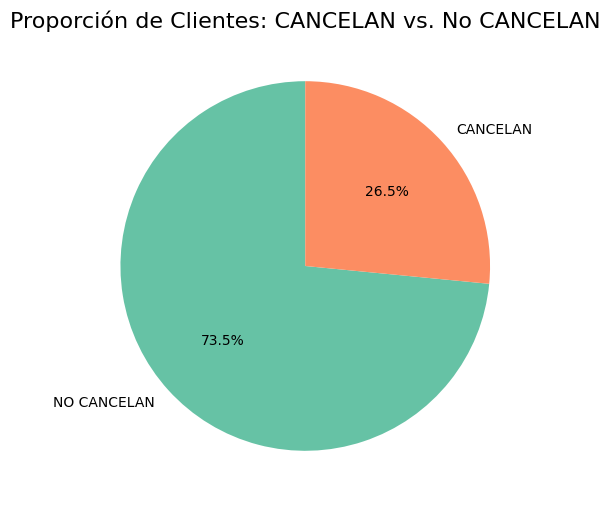

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la proporción de clientes que permanecieron y los que se dieron de baja
churn_counts = datos['churn'].value_counts()

# Renombrar los índices para mayor claridad en el gráfico
churn_counts.index = churn_counts.index.map({0: 'NO CANCELAN', 1: 'CANCELAN'})

# Crear el gráfico de pastel
plt.figure(figsize=(8, 6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Proporción de Clientes: CANCELAN vs. No CANCELAN', fontsize=16)
plt.ylabel('') # Eliminar el label del eje y por defecto
plt.show()

In [64]:
categorical_vars = [
    'account_contract',
    'internet_internetservice',
    'internet_onlinesecurity',
    'internet_techsupport',
    'internet_deviceprotection'
]

# Print the list to confirm
print("Categorical variables selected for analysis:", categorical_vars)

Categorical variables selected for analysis: ['account_contract', 'internet_internetservice', 'internet_onlinesecurity', 'internet_techsupport', 'internet_deviceprotection']


/tmp/ipython-input-57502/2973787713.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn_rate', data=churn_rate, ax=axes[i], palette='viridis')
/tmp/ipython-input-57502/2973787713.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn_rate', data=churn_rate, ax=axes[i], palette='viridis')
/tmp/ipython-input-57502/2973787713.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn_rate', data=churn_rate, ax=axes[i], palette='viridis')
/tmp/ipython-input-57502/2973787713.py:14: FutureWarning: 

Passing

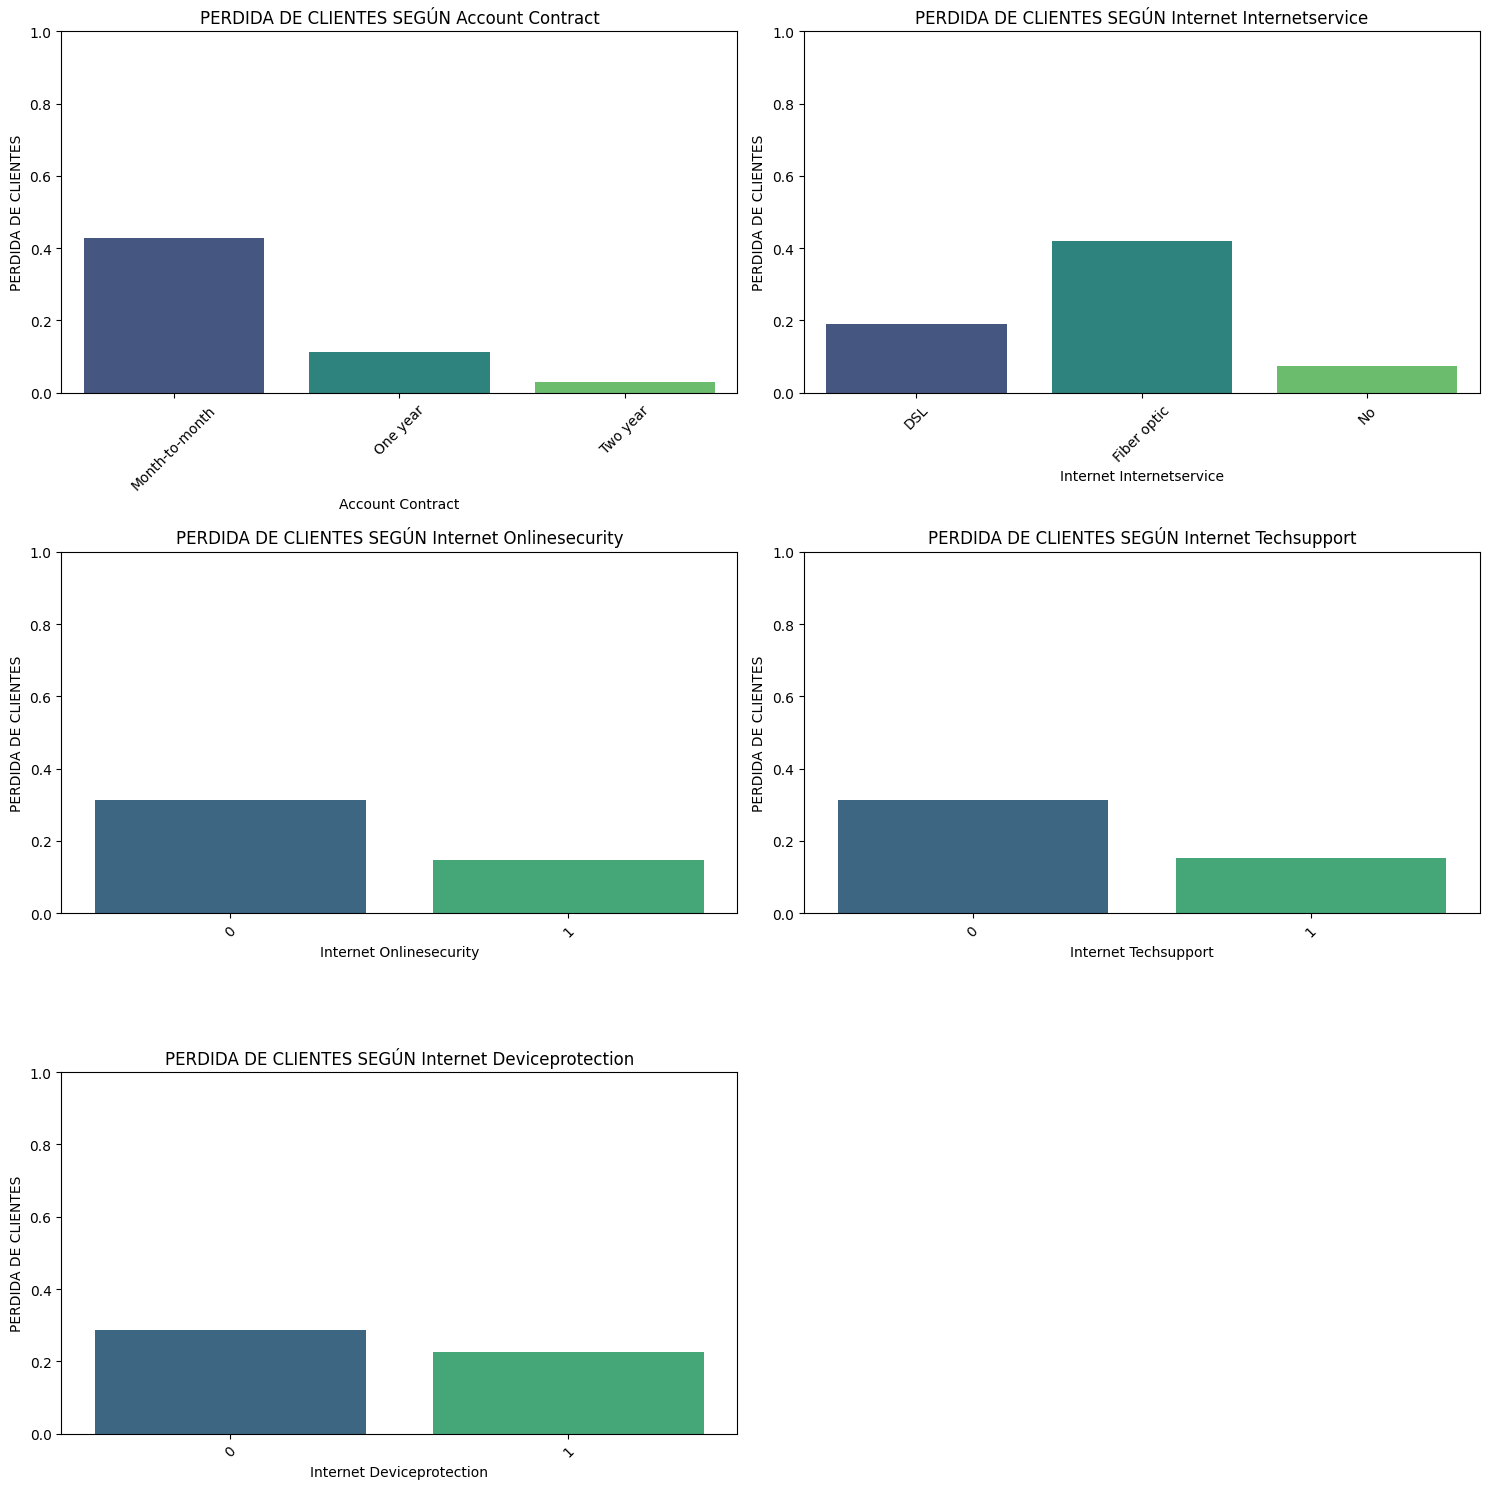

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

# Iterate through each variable and create a bar plot
for i, col in enumerate(categorical_vars):
    # Calculate churn rate for each category
    churn_rate = (datos.groupby(col)['churn'].mean().reset_index())
    churn_rate = churn_rate.rename(columns={'churn': 'churn_rate'})

    # Create the bar plot on the current subplot
    sns.barplot(x=col, y='churn_rate', data=churn_rate, ax=axes[i], palette='viridis')

    # Set title and labels
    axes[i].set_title(f'PERDIDA DE CLIENTES SEGÚN {col.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel(col.replace("_", " ").title(), fontsize=10)
    axes[i].set_ylabel('PERDIDA DE CLIENTES', fontsize=10)
    axes[i].set_ylim(0, 1) # Churn rate is a proportion, so limit y-axis to 0-1
    axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels if they are long

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


#📄Informe final

### Conclusiones del Análisis de Churn por Variables Categóricas

El análisis de la tasa de churn en relación con las variables categóricas seleccionadas ('account_contract', 'internet_internetservice', 'internet_onlinesecurity', 'internet_techsupport', 'internet_deviceprotection') revela patrones importantes:

*   **account_contract (Tipo de Contrato):**
    *   Los clientes con contratos **'Month-to-month'** (mes a mes) presentan una tasa de churn significativamente más alta en comparación con aquellos que tienen contratos de 'One year' (un año) o 'Two year' (dos años). Esto es un hallazgo común, ya que los contratos a corto plazo ofrecen mayor flexibilidad al cliente para cancelar el servicio.
    *   Los contratos a largo plazo ('One year', 'Two year') muestran tasas de churn considerablemente más bajas, lo que indica una mayor lealtad del cliente o barreras de salida más altas.

*   **internet_internetservice (Servicio de Internet):**
    *   Los clientes con **'Fiber optic'** (fibra óptica) tienen la tasa de churn más alta. A pesar de ser un servicio de alta velocidad, esto podría sugerir problemas de calidad de servicio, precio percibido como alto o una mayor competencia en este segmento.
    *   Los clientes con **'DSL'** tienen una tasa de churn moderada, mientras que aquellos que no tienen servicio de internet ('No') tienen la tasa de churn más baja. Esto último es lógico, ya que no están sujetos a la insatisfacción con el servicio de internet.

*   **internet_onlinesecurity, internet_techsupport, internet_deviceprotection (Servicios Adicionales de Internet):**
    *   Para estas tres categorías de servicios adicionales (seguridad en línea, soporte técnico, protección de dispositivos), se observa un patrón consistente: los clientes que NO tienen estos servicios adicionales muestran una tasa de churn más alta que aquellos que SÍ los tienen. Esto sugiere que estos servicios actúan como un factor de retención, aumentando la satisfacción del cliente o la dependencia del servicio, y por lo tanto, reduciendo la probabilidad de churn.
    *   Los clientes que no tienen servicio de internet en absoluto (representado por 'No internet service' que fue binarizado a 0 junto con 'No' en el paso de limpieza) también tienen una tasa de churn más baja en estas categorías, lo cual es esperable ya que estos servicios son complementarios al servicio de internet.

En resumen, para reducir la tasa de churn, Telecom X debería enfocarse en estrategias para convertir clientes de contratos mes a mes a contratos a más largo plazo, analizar y mejorar la experiencia de los clientes de fibra óptica, y promocionar activamente los servicios adicionales como seguridad en línea, soporte técnico y protección de dispositivos para aumentar la retención.